In [1]:
import os

def load_agent_positions(save_dir: str, start_index: int, last_index: int):
    """Load agent positions saved as `{index}_agent_positions.npz`.

    Returns a dict with keys `agent_xy` (concatenated numpy array) and `update_idx`.
    """
    import numpy as _np
    import re

    files = []
    for name in os.listdir(save_dir):
        match = re.match(r"^(\d+)_agent_positions\.npz$", name)
        if match:
            files.append((int(match.group(1)), os.path.join(save_dir, name)))

    if not files:
        raise FileNotFoundError(f"No '*_agent_positions.npz' files found in {save_dir}")

    files.sort(key=lambda x: x[0])
    candidates = files[start_index:last_index]

    if not candidates:
        raise FileNotFoundError("No candidate files available")

    agent_xy_list = []
    update_indices = []

    for selected_idx, fname in candidates:
        with _np.load(fname) as data:
            agent_xy_list.append(data["agent_xy"].copy())
            update_indices.append(int(data["update_idx"]) if "update_idx" in data else selected_idx)

    agent_xy = _np.concatenate(agent_xy_list, axis=0)

    return {"agent_xy": agent_xy, "update_idx": update_indices}


import imageio.v2 as imageio


def _frames_to_mp4(frames, output_path, duration: float = 0.5):
    """Write RGB frames to an mp4 file via imageio/ffmpeg.

    If frame sizes differ, resize all frames to match the last image.
    """
    import numpy as _np
    from PIL import Image

    fps = 1.0 / duration if duration and duration > 0 else 2.0
    target_h, target_w = frames[-1].shape[:2]

    rgb_frames = []
    for img in frames:
        if img.ndim == 3 and img.shape[-1] == 4:
            img = img[..., :3]
        if img.shape[0] != target_h or img.shape[1] != target_w:
            pil_img = Image.fromarray(img)
            pil_img = pil_img.resize((target_w, target_h), Image.Resampling.LANCZOS)
            img = _np.asarray(pil_img)
        rgb_frames.append(img)
    imageio.mimsave(output_path, rgb_frames, fps=fps)


def load_teacher_goal_visuals(
    save_dir: str,
    start_index: int,
    last_index: int,
    output_path=None,
    duration: float = 0.5,
):
    """Load teacher goal count images and create an MP4 animation.

    Expects files named `..._teacher_goal_counts_{update_idx}.png`, sorted by
    update index. Selects the slice `[start_index:last_index]` of that sorted
    list and writes an animation with imageio.

    Returns a dict with keys `video_path`, `update_idx`, and `frames`.
    """
    import re

    files = []
    for name in os.listdir(save_dir):
        # purejaxrl_ppo_brax_ant_u_maze_single_goal_teacher_goal_counts_0.png
        match = re.match(
            r"^purejaxrl_ppo_brax_ant_u_maze_single_goal_teacher_goal_counts_(\d+)\.png$",
            name,
        )
        if match:
            files.append((int(match.group(1)), os.path.join(save_dir, name)))

    if not files:
        raise FileNotFoundError(
            f"No '*_teacher_goal_counts_*.png' files found in {save_dir}"
        )

    files.sort(key=lambda x: x[0])
    candidates = files[start_index:last_index]

    if not candidates:
        raise FileNotFoundError("No candidate files available")

    update_indices = []
    frames = []
    for selected_idx, fname in candidates:
        frames.append(imageio.imread(fname))
        update_indices.append(selected_idx)

    if output_path is None:
        output_path = os.path.join(
            save_dir, f"teacher_goal_visuals_{start_index}_{last_index}.mp4"
        )

    _frames_to_mp4(frames, output_path, duration=duration)
    print(f"Saved teacher goal visuals to {output_path}")

    return {
        "video_path": output_path,
        "update_idx": update_indices,
        "frames": frames,
    }


def load_empowerment_visuals(
    save_dir: str,
    start_index: int,
    last_index: int,
    output_path=None,
    duration: float = 0.5,
):
    """Load teacher empowerment images and create an MP4 animation.

    Expects files named `..._teacher_empowerment_grid_{update_idx}.png`, sorted
    by update index. Selects the slice `[start_index:last_index]` of that sorted
    list and writes an animation with imageio.

    Returns a dict with keys `video_path`, `update_idx`, and `frames`.
    """
    import re

    files = []
    for name in os.listdir(save_dir):
        # purejaxrl_ppo_brax_ant_u_maze_single_goal_teacher_empowerment_grid_0.png
        match = re.match(
            r"^purejaxrl_ppo_brax_ant_u_maze_single_goal_teacher_empowerment_grid_(\d+)\.png$",
            name,
        )
        if match:
            files.append((int(match.group(1)), os.path.join(save_dir, name)))

    if not files:
        raise FileNotFoundError(
            f"No '*_teacher_empowerment_grid_*.png' files found in {save_dir}"
        )

    files.sort(key=lambda x: x[0])
    candidates = files[start_index:last_index]

    if not candidates:
        raise FileNotFoundError("No candidate files available")

    update_indices = []
    frames = []
    for selected_idx, fname in candidates:
        frames.append(imageio.imread(fname))
        update_indices.append(selected_idx)

    if output_path is None:
        output_path = os.path.join(
            save_dir, f"teacher_empowerment_visuals_{start_index}_{last_index}.mp4"
        )

    _frames_to_mp4(frames, output_path, duration=duration)
    print(f"Saved teacher empowerment visuals to {output_path}")

    return {
        "video_path": output_path,
        "update_idx": update_indices,
        "frames": frames,
    }

(-44.100971412658694,
 51.037887763977054,
 -30.738597202301026,
 55.073716449737546)

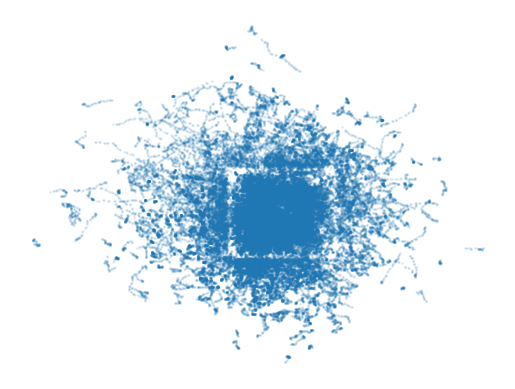

In [3]:
exp_path = "/network/scratch/f/faisal.mohamed/purejaxrl_emp_teachers/race_64740703"
positions_path = os.path.join(exp_path, "agent_positions")
goal_counts_path = os.path.join(exp_path, "teacher_goal_visuals")
empowerment_path = os.path.join(exp_path, "teacher_empowerment_visuals")
start = 1
end = 10000000000
output = load_agent_positions(positions_path, start, end)
xy = output["agent_xy"]
import matplotlib.pyplot as plt
plt.scatter(xy[:, 0], xy[:, 1], s=1, alpha=0.1)
plt.axis("off")

In [6]:
output = load_teacher_goal_visuals(goal_counts_path, start, end, duration=0.25)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (915, 817) to (928, 832) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved teacher goal visuals to /network/scratch/f/faisal.mohamed/purejaxrl_emp_teachers/race_64740703/teacher_goal_visuals/teacher_goal_visuals_1_10000000000.mp4


In [7]:
output = load_empowerment_visuals(empowerment_path, start, end, duration=0.25)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (990, 817) to (992, 832) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved teacher empowerment visuals to /network/scratch/f/faisal.mohamed/purejaxrl_emp_teachers/race_64740703/teacher_empowerment_visuals/teacher_empowerment_visuals_1_10000000000.mp4
